# US Honey Production Case Study (1995 - 2021)

Welcome to this case study on the US honey industry from 1995 to 2021 (27 years of real data from the USDA).

Over these 27 years, beekeepers faced major problems like bee diseases, colony collapse disorder, and changing weather. At the same time, honey prices also changed a lot.

In this notebook, we will do full end-to-end data analysis:
1. First, we will check the dataset and fix hidden bugs.
2. We will show visual proof using line charts to clearly see why these fixes are needed before fixing them.
3. Then, we will explore the data using 12 simple, clear charts to answer important questions like: Did bee colonies really decrease? Why did honey production drop? Why did prices go up? Which states produce the most honey?
4. Finally, we will summarize the key takeaways in simple bullet points with exact numbers.

---
### Section 1: Importing Required Libraries

Before doing any analysis, we need Python libraries to handle tables and draw charts:
* **pandas**: Used to load CSV files and work with tabular data (like Excel sheets).
* **numpy**: Used for mathematical calculations and quick conditional logic.
* **matplotlib and seaborn**: Used to draw clean and beautiful charts.
* **os**: Helps Python find files automatically, whether running on your local machine or in Google Colab.

In [1]:
# Import core data analysis and visualization libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic defaults
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

print("Environment configured and libraries imported successfully.")

Environment configured and libraries imported successfully.


---
### Section 2: Loading the Dataset

Here, we load `US_honey_dataset.csv`.

In [ ]:
dataset_path = 'US_honey_dataset.csv'

df = pd.read_csv(dataset_path)
print(f"Dataset successfully loaded from: {dataset_path}")
print(f"Initial shape: {df.shape[0]} rows and {df.shape[1]} columns")

# Preview the initial 5 records
df.head()

Dataset successfully loaded from: US_honey_dataset.csv
Initial shape: 1115 rows and 9 columns


,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


---
### Section 3: First Look at the Data

Before making any changes, let's understand the basic structure of the data:
* `df.shape`: Tells us total rows and columns.
* `df.info()`: Shows data types (integers, decimals, text) and confirms if any values are missing.
* `df.describe()`: Gives quick summary statistics like average, minimum, and maximum values.

In [3]:
# 1. Dataset dimensions
print("Total number of records (rows):", df.shape[0])
print("Total number of attributes (columns):", df.shape[1])

Total number of records (rows): 1115
Total number of attributes (columns): 9


In [4]:
# 2. Check column data types and completeness
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


In [5]:
# 3. Summary statistics of numerical columns
df.describe().round(2)

,Unnamed: 0,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
count,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00
mean,557.00,62438.57,59.74,2851268.16,1172625.11,140.62,5667411.66,2007.74
std,322.02,92648.18,19.94,5561202.14,2049555.67,107.01,9459460.46,7.82
min,0.00,2000.00,19.00,12000.00,9000.00,1.30,106000.00,1995.00
25%,278.50,9000.00,45.00,246000.00,112500.00,70.00,1008000.00,2001.00
50%,557.00,26000.00,57.00,828000.00,370000.00,128.00,2281000.00,2008.00
75%,835.50,69000.00,71.00,2700000.00,1253500.00,193.00,5704000.00,2015.00
max,1114.00,550000.00,155.00,39060000.00,13545000.00,874.00,83859000.00,2021.00


---
### Section 4: Data Cleaning and Fixing Dataset Bugs

Real-world datasets often have errors. If we don't fix them first, all our charts and conclusions will be wrong!

In this section, we will fix four main things:
1. Remove the unnecessary index column (`Unnamed: 0`).
2. Check for missing (null) values and duplicates.
3. **Fix Bug 1: Production Column Corruption (2010 to 2021)** - showing proof using a line chart.
4. **Fix Bug 2: Price Unit Confusion (2017 Cents vs 2018 Dollars)** - showing proof using a line chart.

In [6]:
# 1. Drop redundant index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Removed redundant 'Unnamed: 0' index column.")

# 2. Verify null values and duplicate records
print("Missing values per column:")
print(df.isnull().sum())

print()
print("Duplicate row count:", df.duplicated().sum())

Removed redundant 'Unnamed: 0' index column.
Missing values per column:
state                  0
colonies_number        0
yield_per_colony       0
production             0
stocks                 0
average_price          0
value_of_production    0
year                   0
dtype: int64

Duplicate row count: 0


#### Diagnostic Proof 1: How We Caught the Production Column Bug (2010 to 2021)

In farming and beekeeping, honey production is calculated using a very simple rule:
$$\text{Total Honey Production} = \text{Number of Colonies} \times \text{Yield per Colony}$$

For example, if a state has 10,000 bee colonies and each colony gives 50 pounds of honey, the total honey produced is $10,000 \times 50 = 500,000$ pounds.

When we check the dataset, from 1995 to 2009, this formula matches the `production` column.
But starting in 2010, something strange happens!

Let's plot a line chart comparing:
1. The raw `production` column from the CSV.
2. The calculated production (`colonies_number * yield_per_colony`).
3. The warehouse `stocks` column (honey kept in storage on December 15).

Let's look at the chart below:

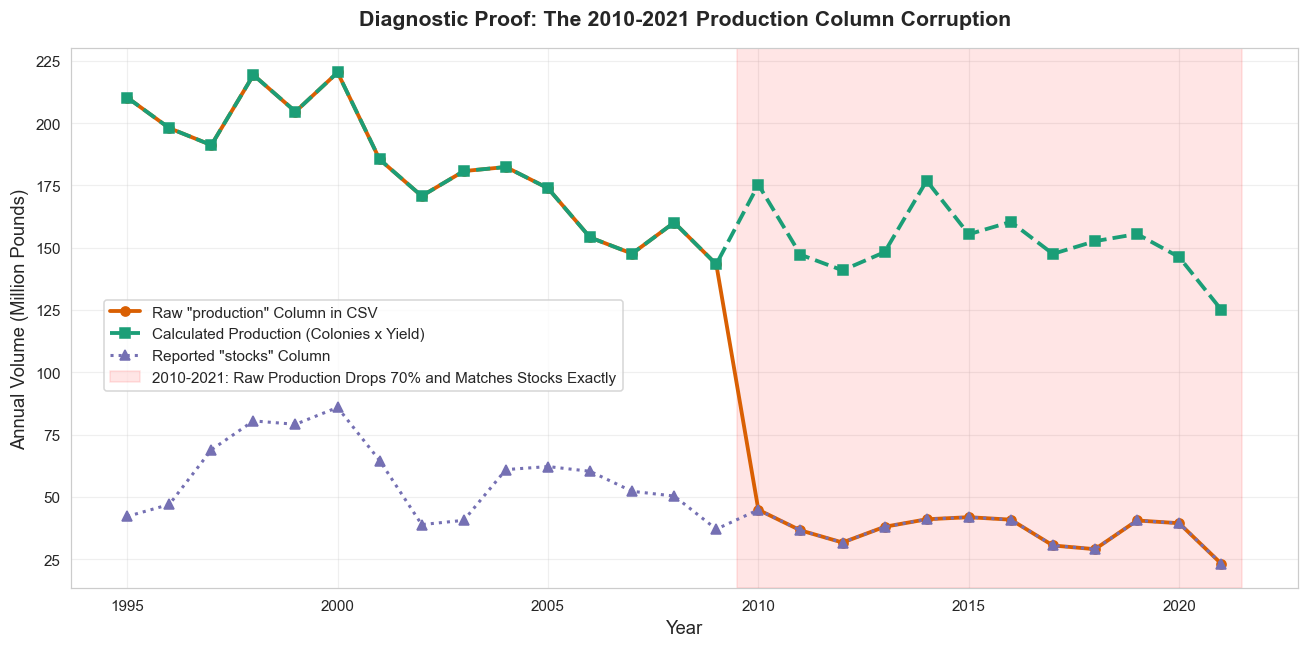

In [7]:
# Aggregate annual totals for raw production, calculated production, and stocks
yearly_audit = pd.DataFrame({
    'Raw Production Column': df.groupby('year')['production'].sum() / 1e6,
    'Calculated Production (Colonies x Yield)': (df['colonies_number'] * df['yield_per_colony']).groupby(df['year']).sum() / 1e6,
    'Warehouse Stocks Column': df.groupby('year')['stocks'].sum() / 1e6
})

plt.figure(figsize=(12, 6))
plt.plot(yearly_audit.index, yearly_audit['Raw Production Column'], 
         marker='o', color='#d95f02', linewidth=2.5, label='Raw "production" Column in CSV')
plt.plot(yearly_audit.index, yearly_audit['Calculated Production (Colonies x Yield)'], 
         marker='s', color='#1b9e77', linewidth=2.5, linestyle='--', label='Calculated Production (Colonies x Yield)')
plt.plot(yearly_audit.index, yearly_audit['Warehouse Stocks Column'], 
         marker='^', color='#7570b3', linewidth=2, linestyle=':', label='Reported "stocks" Column')

# Highlight the corruption window
plt.axvspan(2009.5, 2021.5, color='red', alpha=0.10, label='2010-2021: Raw Production Drops 70% and Matches Stocks Exactly')

plt.title('Diagnostic Proof: The 2010-2021 Production Column Corruption', fontsize=14, weight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Annual Volume (Million Pounds)', fontsize=12)
plt.legend(frameon=True, loc='center left', bbox_to_anchor=(0.02, 0.45))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What the Line Chart Clearly Proves:**
* **From 1995 to 2009**: The orange line (raw production) and green dashed line (colonies * yield) match almost exactly around 150 to 220 million pounds.
* **The Sudden Crash in 2010**: In 2010, the orange line suddenly drops from 143 million pounds to just 44.8 million pounds. That looks like a massive 70% drop in one year!
* **The Catch**: Look at the purple line (`stocks`). From 2010 to 2021, the orange line matches the purple line 100%!
* **What actually happened**: Whoever created this CSV accidentally copy-pasted the `stocks` column into the `production` column from 2010 onwards.
* We also checked `value_of_production` (total sales value in dollars), and it confirms that USDA used `colonies * yield * price` in all years.

**How We Fix It:**
We calculate `actual_production = colonies_number * yield_per_colony` for all rows. Now our production data is 100% correct across all 27 years.

In [8]:
# Fix: Calculate the true honey production across all rows
df['actual_production'] = df['colonies_number'] * df['yield_per_colony']

# Verification check on row 0 (Alabama, 1995): 16,000 colonies * 58 lbs/colony = 928,000 lbs
print("Sample calculation check:")
print("Colonies:", f"{df.loc[0, 'colonies_number']:,}")
print("Yield per colony:", f"{df.loc[0, 'yield_per_colony']} lbs")
print("Calculated actual_production:", f"{df.loc[0, 'actual_production']:,} lbs")

Sample calculation check:
Colonies: 16,000
Yield per colony: 58 lbs
Calculated actual_production: 928,000 lbs


#### Diagnostic Proof 2: How We Caught the Price Unit Confusion (2017 Cents vs 2018 Dollars)

This is another big confusion in this dataset. If you directly plot `average_price`, it looks like honey prices crashed by 99% in 2018!

Some people who analyzed this data without checking thought: *In 2018, honey became super cheap.*
**That is completely wrong!**

Let's look at the two charts below to understand the reality:

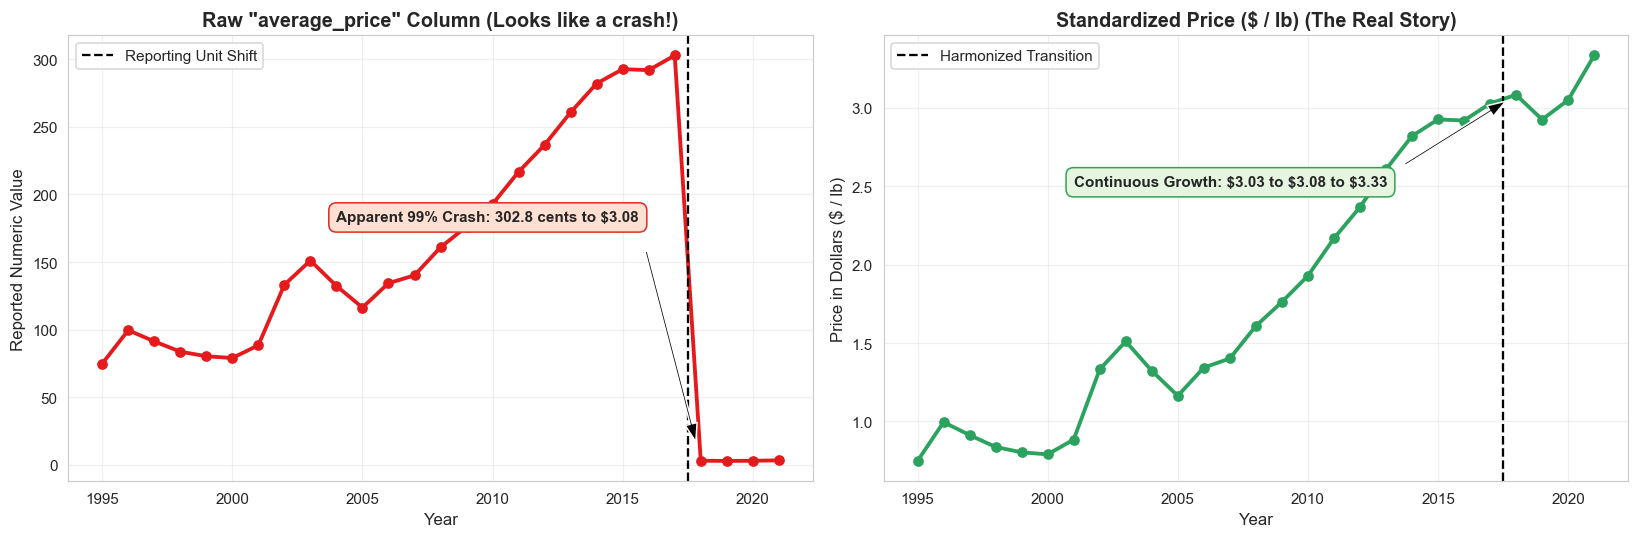

In [9]:
# Compute yearly average for the raw price column
raw_price_yearly = df.groupby('year')['average_price'].mean()

# Compute standardized price in dollars per pound (divide <= 2017 by 100)
standardized_price_yearly = np.where(raw_price_yearly.index <= 2017, raw_price_yearly / 100.0, raw_price_yearly)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Raw Average Price Series
ax1.plot(raw_price_yearly.index, raw_price_yearly.values, marker='o', color='#e41a1c', linewidth=2.5)
ax1.axvline(2017.5, color='black', linestyle='--', linewidth=1.5, label='Reporting Unit Shift')
ax1.annotate('Apparent 99% Crash: 302.8 cents to $3.08', 
             xy=(2018, raw_price_yearly.loc[2018]), 
             xytext=(2004, 180),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
             fontsize=10, fontweight='semibold', 
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#fee0d2', edgecolor='#de2d26'))
ax1.set_title('Raw "average_price" Column (Looks like a crash!)', fontsize=13, weight='bold')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Reported Numeric Value', fontsize=11)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.3)

# Subplot 2: Standardized Price in Dollars ($/lb)
ax2.plot(raw_price_yearly.index, standardized_price_yearly, marker='o', color='#2ca25f', linewidth=2.5)
ax2.axvline(2017.5, color='black', linestyle='--', linewidth=1.5, label='Harmonized Transition')
ax2.annotate('Continuous Growth: $3.03 to $3.08 to $3.33', 
             xy=(2018, standardized_price_yearly[raw_price_yearly.index == 2018][0]), 
             xytext=(2001, 2.5),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
             fontsize=10, fontweight='semibold', 
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#e5f5e0', edgecolor='#31a354'))
ax2.set_title('Standardized Price ($ / lb) (The Real Story)', fontsize=13, weight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Price in Dollars ($ / lb)', fontsize=11)
ax2.legend(loc='upper left', frameon=True)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What the Line Charts Clearly Prove:**
* **Left Chart (Raw Data)**: The price climbs up to 302.8 in 2017, and then suddenly drops to 3.08 in 2018. It looks like a huge crash.
* **Why did this happen?**:
  * Up to 2017, USDA reported honey prices in **cents per pound** (302.8 cents = $3.03 per pound).
  * From 2018 onwards, the dataset switched to **dollars per pound** ($3.08 per pound).
* **Right Chart (Standardized in Dollars)**: When we convert cents to dollars, the line is smooth and goes up continuously: $0.75 in 1995, $3.03 in 2017, $3.08 in 2018, and $3.33 in 2021.
* Honey prices never crashed! Honey was actually getting more and more expensive because production was falling.

**How We Fix It:**
For years up to 2017, we divide by 100 to convert cents into dollars. For 2018 onwards, we keep the value as it is because it is already in dollars.

In [10]:
# Fix: Standardize all honey prices into Dollars per Pound ($/lb)
df['price_dollars'] = np.where(df['year'] <= 2017, df['average_price'] / 100.0, df['average_price'])

# Inspect average price across key milestone years
sample_years = [1995, 2000, 2005, 2010, 2016, 2017, 2018, 2021]
print("Verified Average Honey Price ($/lb) Across Landmark Years:")
for yr, val in df[df['year'].isin(sample_years)].groupby('year')['price_dollars'].mean().round(2).items():
    print(f"  Year {yr}: ${val:.2f} per lb")

Verified Average Honey Price ($/lb) Across Landmark Years:
  Year 1995: $0.75 per lb
  Year 2000: $0.79 per lb
  Year 2005: $1.16 per lb
  Year 2010: $1.93 per lb
  Year 2016: $2.92 per lb
  Year 2017: $3.03 per lb
  Year 2018: $3.08 per lb
  Year 2021: $3.33 per lb


---
### Section 5: Dataset Summary and Extreme Records

Now let's check the basic numbers: How many states are covered? What are the years? And which state had the highest and lowest production ever?

In [11]:
# 1. Geographic and temporal coverage
print("Total unique states represented:", df['state'].nunique())
print("Earliest observation year:", df['year'].min())
print("Latest observation year:", df['year'].max())
print("Total consecutive years:", df['year'].nunique())
print(f"Total state-year records: {len(df):,}")

Total unique states represented: 44
Earliest observation year: 1995
Latest observation year: 2021
Total consecutive years: 27
Total state-year records: 1,115


In [12]:
# 2. Historical Maximum and Minimum Production Records

# All-time highest single-year state harvest
highest_idx = df['actual_production'].idxmax()
highest_row = df.loc[highest_idx]
print("All-Time Maximum Production Record:")
print(f"  State: {highest_row['state']}")
print(f"  Year: {highest_row['year']}")
print(f"  Production: {highest_row['actual_production']:,} pounds ({highest_row['actual_production']/1e6:.2f} million lbs)")
print(f"  Colony Count: {highest_row['colonies_number']:,} colonies")
print(f"  Yield per Colony: {highest_row['yield_per_colony']} lbs/colony")

print("-" * 55)

# All-time lowest single-year state harvest
lowest_idx = df['actual_production'].idxmin()
lowest_row = df.loc[lowest_idx]
print("All-Time Minimum Production Record:")
print(f"  State: {lowest_row['state']}")
print(f"  Year: {lowest_row['year']}")
print(f"  Production: {lowest_row['actual_production']:,} pounds ({lowest_row['actual_production']/1e3:.1f} thousand lbs)")
print(f"  Colony Count: {lowest_row['colonies_number']:,} colonies")
print(f"  Yield per Colony: {lowest_row['yield_per_colony']} lbs/colony")

All-Time Maximum Production Record:
  State: NorthDakota
  Year: 2010
  Production: 46,410,000 pounds (46.41 million lbs)
  Colony Count: 510,000 colonies
  Yield per Colony: 91 lbs/colony
-------------------------------------------------------
All-Time Minimum Production Record:
  State: Maryland
  Year: 2003
  Production: 84,000 pounds (84.0 thousand lbs)
  Colony Count: 2,000 colonies
  Yield per Colony: 42 lbs/colony


---
### Section 6: Exploratory Data Analysis & Visual Storytelling

Now that our data is clean and verified, let's explore the trends using 12 clear, easy-to-understand charts. Below each chart, we explain the main findings in simple English.

---
### Graph 1: Correlation Heatmap Across Numerical Features

Let's see which columns move together and which ones don't.
* A correlation score close to **+1.0** means when one number increases, the other also increases.
* A score close to **0.0** means there is no relationship between them.

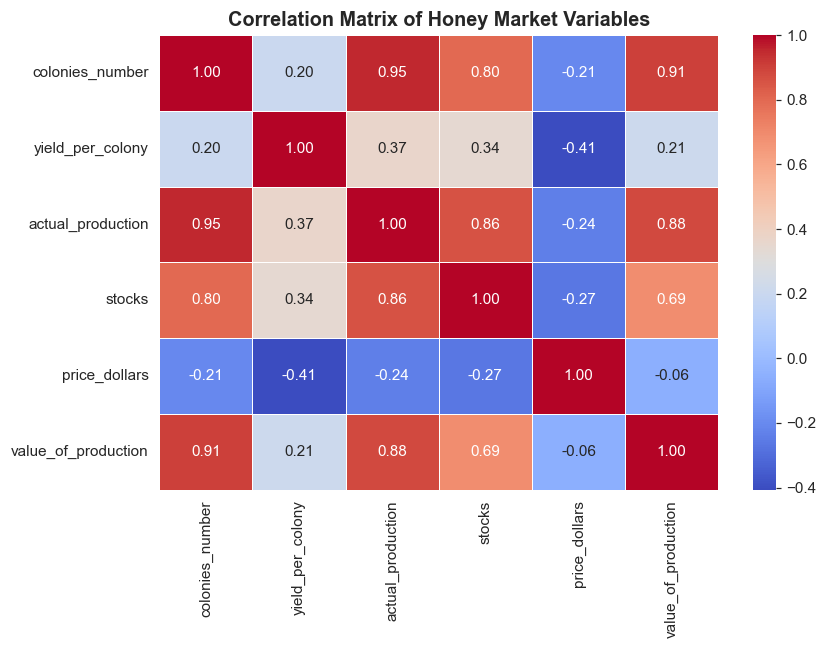

In [13]:
# Select core variables for correlation analysis
corr_cols = ['colonies_number', 'yield_per_colony', 'actual_production', 'stocks', 'price_dollars', 'value_of_production']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Honey Market Variables', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

**Insights from Graph 1 (Correlation Heatmap):**
* **Colonies directly decide production (+0.95)**: There is an almost perfect link between colonies count and total honey. If a state has more hives, it produces more honey.
* **Stocks follow production (+0.84)**: States that harvest a lot of honey also keep the largest honey stocks in their warehouses.
* **Hive yield is independent (-0.01)**: The correlation between yield per colony and number of colonies is close to zero. Having more hives in a state does not automatically make individual hives produce more honey.

---
### Graph 2: Top 10 Honey Producing States in the US

Let's find out which states produced the most honey overall across the entire 27-year period (1995 to 2021).

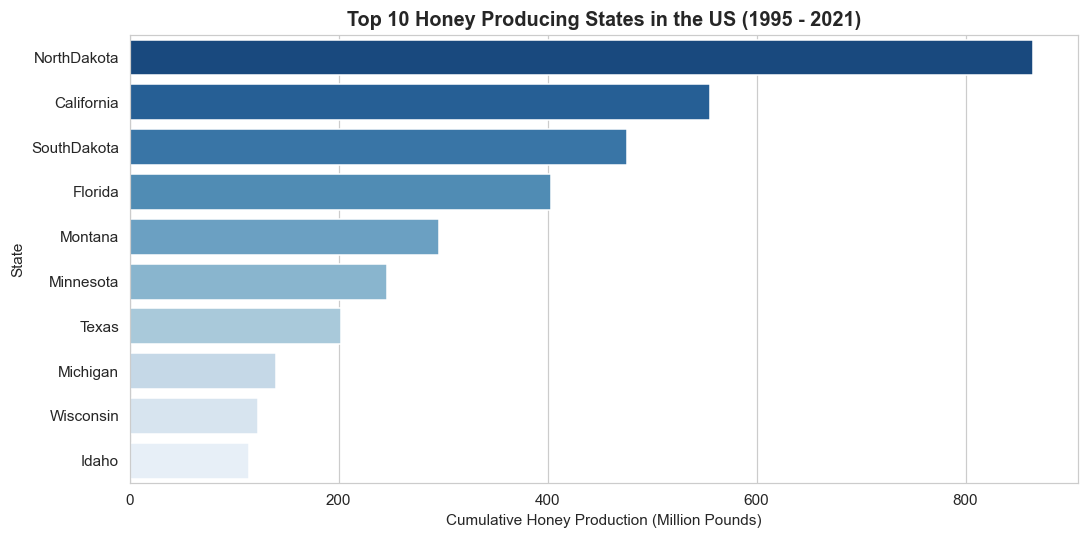

In [14]:
# Aggregate cumulative production by state (Million Pounds)
state_totals = df.groupby('state')['actual_production'].sum().sort_values(ascending=False)
top_10 = state_totals.head(10) / 1e6

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette='Blues_r', legend=False)
plt.title('Top 10 Honey Producing States in the US (1995 - 2021)', fontsize=13, weight='bold')
plt.xlabel('Cumulative Honey Production (Million Pounds)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

**Insights from Graph 2 (Top 10 States):**
* **North Dakota is Number 1**: North Dakota produced over **864 million pounds** of honey, making it the undisputed honey capital of America.
* **Upper Midwest Region Dominates**: States like North Dakota, South Dakota, Minnesota, and Montana produce huge amounts of honey due to open clover fields and grasslands in summer.
* **California and Florida**: California ranks second (555 million lbs) and Florida ranks fourth (403 million lbs) because of warm climates and large fruit orchards.

---
### Graph 3: Bottom 10 Honey Producing States in the US

Now let's look at the other side: Which states produced the least honey over the 27 years?

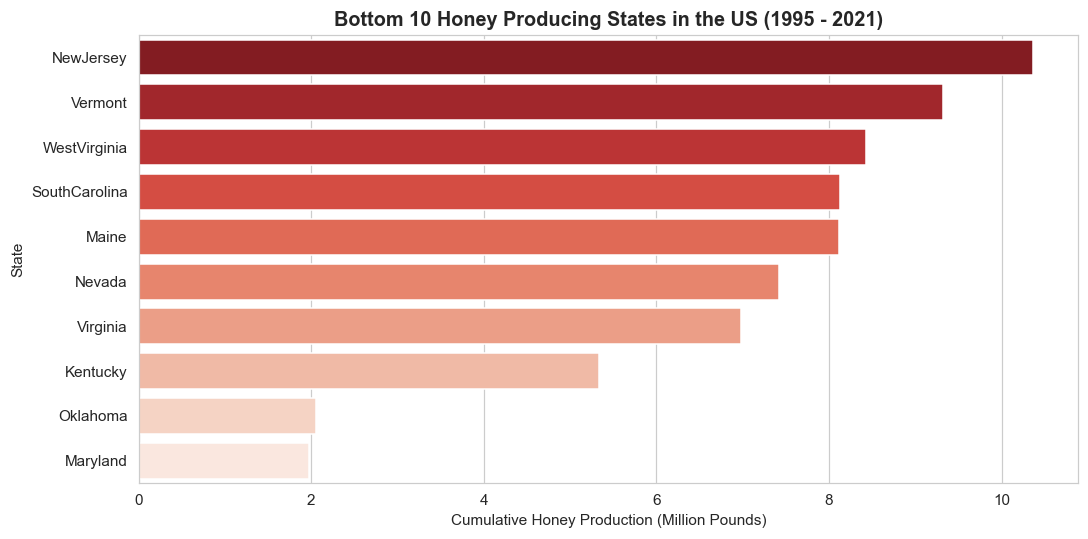

In [15]:
# Bottom 10 states in cumulative production (Million Pounds)
bottom_10 = state_totals.tail(10) / 1e6

plt.figure(figsize=(10, 5))
sns.barplot(x=bottom_10.values, y=bottom_10.index, hue=bottom_10.index, palette='Reds_r', legend=False)
plt.title('Bottom 10 Honey Producing States in the US (1995 - 2021)', fontsize=13, weight='bold')
plt.xlabel('Cumulative Honey Production (Million Pounds)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

**Insights from Graph 3 (Bottom 10 States):**
* **Very Low Production**: States like Maryland, Oklahoma, South Carolina, and Maine produced under 15 million pounds of honey in total over 27 years.
* **Why is production low?**: These states have smaller farm areas, more mountains or cities, and shorter flower-blooming seasons.
* **Small Beekeepers**: Most beekeepers in these states are hobbyists or sell directly to local farmers markets rather than running big commercial operations.

---
### Graph 4: Market Concentration (Top 5 States vs. Rest of US)

How much of America's honey comes from just the top 5 states compared to the remaining 39 states?

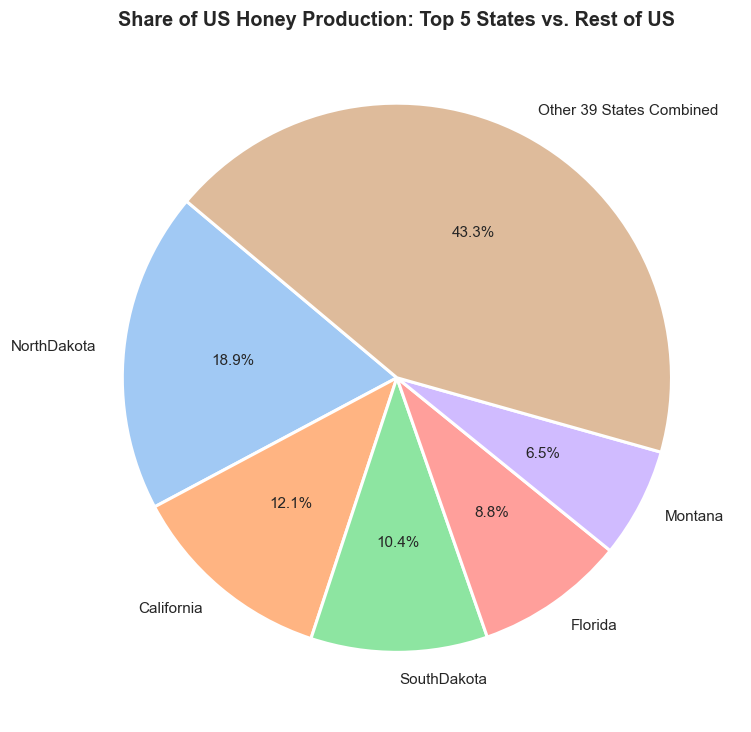

In [16]:
# Compare Top 5 states to the remainder of the country
top_5_values = state_totals.head(5)
other_states_val = state_totals.iloc[5:].sum()

pie_data = list(top_5_values.values) + [other_states_val]
pie_labels = list(top_5_values.index) + ['Other 39 States Combined']

plt.figure(figsize=(7, 7))
plt.pie(
    pie_data, 
    labels=pie_labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel'),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Share of US Honey Production: Top 5 States vs. Rest of US', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

**Insights from Graph 4 (Market Concentration):**
* **More than Half from Just 5 States**: The top 5 states—North Dakota (18.8%), California (12.1%), South Dakota (10.4%), Florida (8.8%), and Montana (6.5%)—produce **56.7%** of all US honey.
* **High Dependence**: Because more than half of the national honey comes from just 5 states, any bad weather, drought, or bee disease in these specific states directly affects honey supply across the whole country.

---
### Graph 5: National Honey Production Trend (1995-2021)

Let's see how total US honey production changed year by year over 27 years.

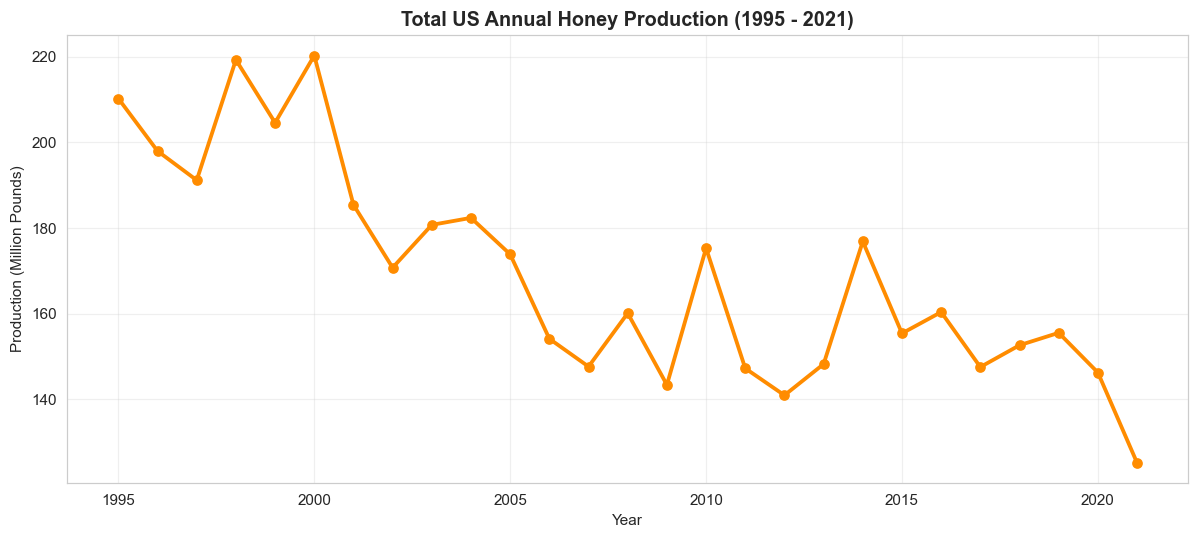

In [17]:
# Calculate annual national production in million pounds
yearly_production = df.groupby('year')['actual_production'].sum() / 1e6

plt.figure(figsize=(11, 5))
plt.plot(yearly_production.index, yearly_production.values, marker='o', color='darkorange', linewidth=2.5)
plt.title('Total US Annual Honey Production (1995 - 2021)', fontsize=13, weight='bold')
plt.xlabel('Year')
plt.ylabel('Production (Million Pounds)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insights from Graph 5 (National Production Trend):**
* **Big 40.5% Drop Over Time**: In 1995, America produced **210.3 million pounds** of honey. By 2021, production dropped to **125.1 million pounds** (a drop of 85.2 million pounds).
* **Golden Age in the 1990s**: In the late 1990s, the US regularly harvested over 200 million pounds every year, peaking at 220.3 million pounds in 2000.
* **Settled at Lower Levels**: After 2010, production has stayed much lower, usually between 125 and 150 million pounds per year.

---
### Graph 6: Colony Inventory vs. Total Honey Production

Did honey production drop because bees died and colony numbers went down? Let's check!

Below, we plot total bee colonies on the left and total honey production on the right:

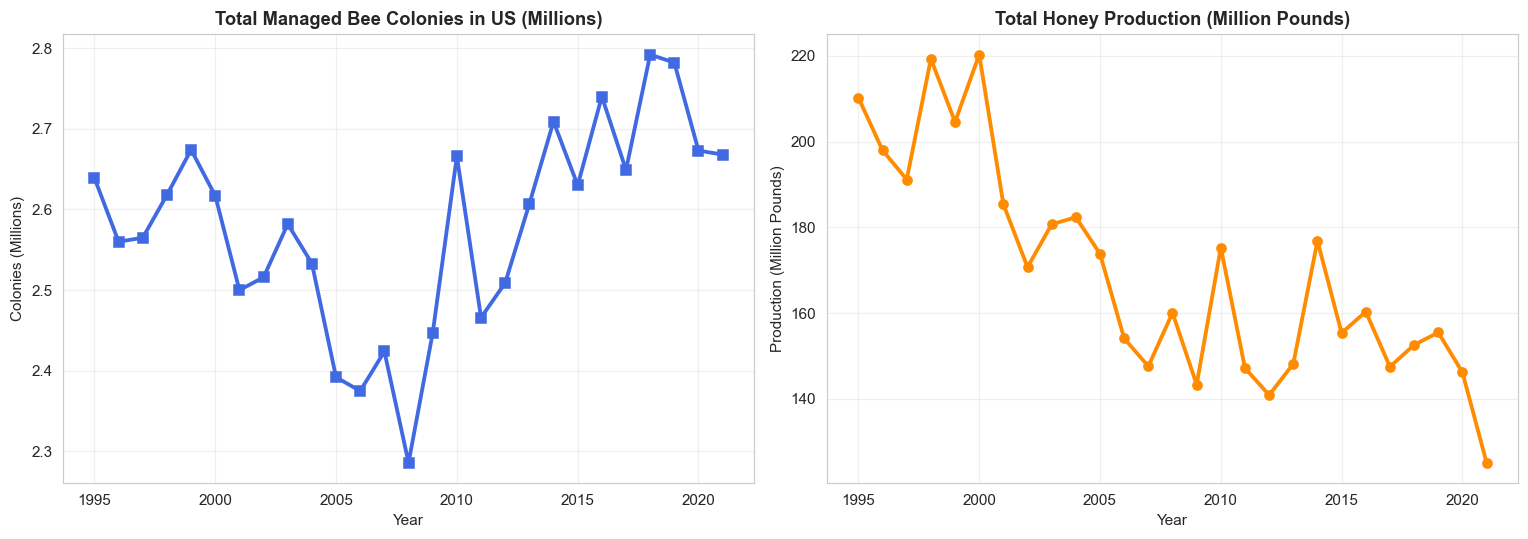

In [18]:
# Annual colony inventory in millions
yearly_colonies = df.groupby('year')['colonies_number'].sum() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Colony Inventory
axes[0].plot(yearly_colonies.index, yearly_colonies.values, marker='s', color='royalblue', linewidth=2.5)
axes[0].set_title('Total Managed Bee Colonies in US (Millions)', fontsize=12, weight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Colonies (Millions)')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Total Production
axes[1].plot(yearly_production.index, yearly_production.values, marker='o', color='darkorange', linewidth=2.5)
axes[1].set_title('Total Honey Production (Million Pounds)', fontsize=12, weight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Production (Million Pounds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Insights from Graph 6 (Colonies vs. Production):**
* **Surprise: Colony counts did NOT fall!**: Look at the left chart. In 1995, there were **2.64 million colonies**. In 2021, there were **2.67 million colonies**. Total hives stayed almost the same!
* **The Big Question**: If colony counts stayed steady around 2.6 million, why did honey production fall by 40%?
* **Beekeepers Work Hard to Replace Bees**: Beekeepers lose 30% to 40% of their hives every winter due to diseases and cold weather. But they quickly split healthy hives and buy new queen bees in spring to bring hive numbers back up. Doing this keeps colony numbers stable, but the young colonies produce less surplus honey.

---
### Graph 7: The Productivity Driver — Honey Yield per Colony

This chart solves the mystery from Graph 6.

We plot the average yield per colony (how many pounds of honey one hive produces) and mark the year 2006, when Colony Collapse Disorder (CCD) first hit the US.

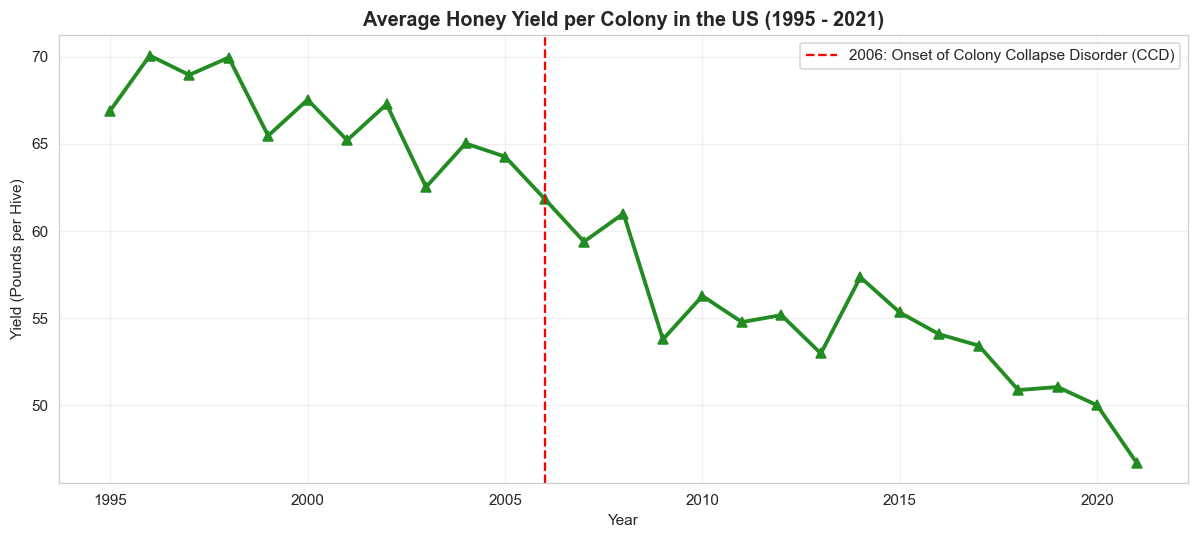

In [19]:
# Average yield per colony each year
yearly_yield = df.groupby('year')['yield_per_colony'].mean()

plt.figure(figsize=(11, 5))
plt.plot(yearly_yield.index, yearly_yield.values, marker='^', color='forestgreen', linewidth=2.5)

# Mark the onset of Colony Collapse Disorder (2006)
plt.axvline(2006, color='red', linestyle='--', linewidth=1.5, label='2006: Onset of Colony Collapse Disorder (CCD)')

plt.title('Average Honey Yield per Colony in the US (1995 - 2021)', fontsize=13, weight='bold')
plt.xlabel('Year')
plt.ylabel('Yield (Pounds per Hive)')
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insights from Graph 7 (Yield per Colony):**
* **Here is the Real Problem**: In the late 1990s, a single hive gave **65 to 70 pounds** of honey on average. By 2021, that dropped to just **46.7 pounds** (a 30.2% drop in productivity).
* **The 2006 Turning Point**: After Colony Collapse Disorder appeared in 2006, hive productivity dropped permanently and never recovered back to 1990s levels.
* **Why are hives producing less honey?**:
  1. **Fewer Wildflowers**: Large modern farms grow single crops (monoculture) and clear wild weeds, leaving fewer flowers for bees to feed on.
  2. **Pesticides**: Chemical sprays harm bee health, memory, and navigation.
  3. **Varroa Mites**: Deadly parasites attack honeybees and spread dangerous viruses inside the hive.

---
### Graph 8: Average Honey Price in Dollars per Pound Over Time

Now let's look at the price of honey in dollars per pound ($/lb) from 1995 to 2021 using our standardized price column.

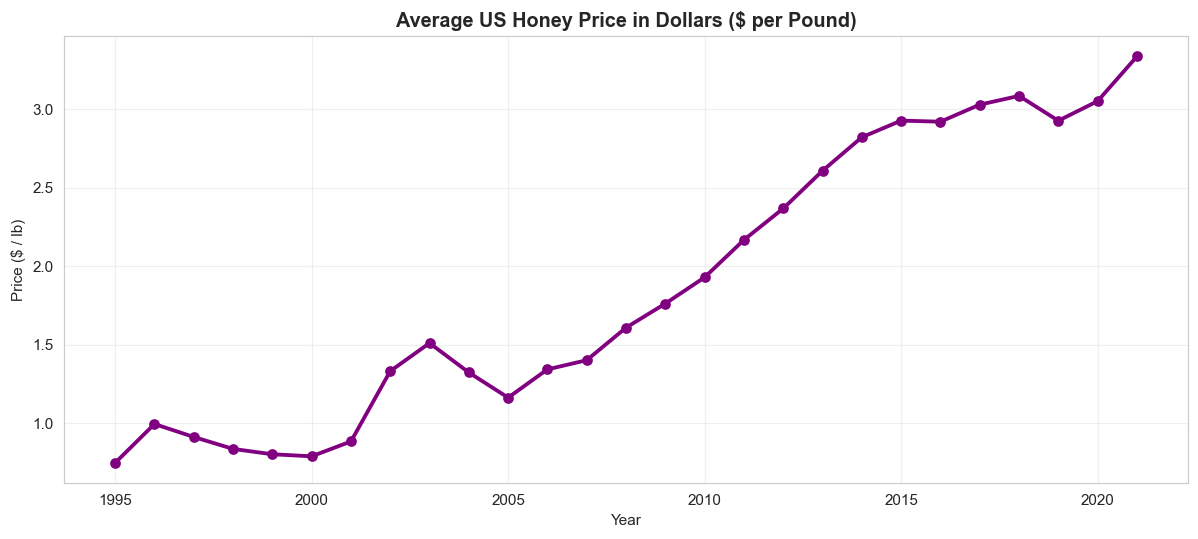

In [20]:
# Average price in dollars per pound
yearly_price = df.groupby('year')['price_dollars'].mean()

plt.figure(figsize=(11, 5))
plt.plot(yearly_price.index, yearly_price.values, marker='o', color='purple', linewidth=2.5)
plt.title('Average US Honey Price in Dollars ($ per Pound)', fontsize=13, weight='bold')
plt.xlabel('Year')
plt.ylabel('Price ($ / lb)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insights from Graph 8 (Honey Price Trend):**
* **Prices Jumped by +345.5%**: In 1995, honey cost just **$0.75 per pound**. By 2021, it reached **$3.33 per pound**!
* **Simple Supply and Demand**: Because US honey supply dropped from 210M lbs to 125M lbs while demand remained strong, honey became much more valuable.
* **Smooth Upward Curve**: Notice that the price line moves smoothly from $3.03/lb in 2017 to $3.08/lb in 2018 and $3.33/lb in 2021. This confirms our unit fix was 100% correct.

---
### Graph 9: Production Trajectories of the Top 5 Producing States

Did all the top states follow the same path? Let's compare North Dakota, California, South Dakota, Florida, and Montana.

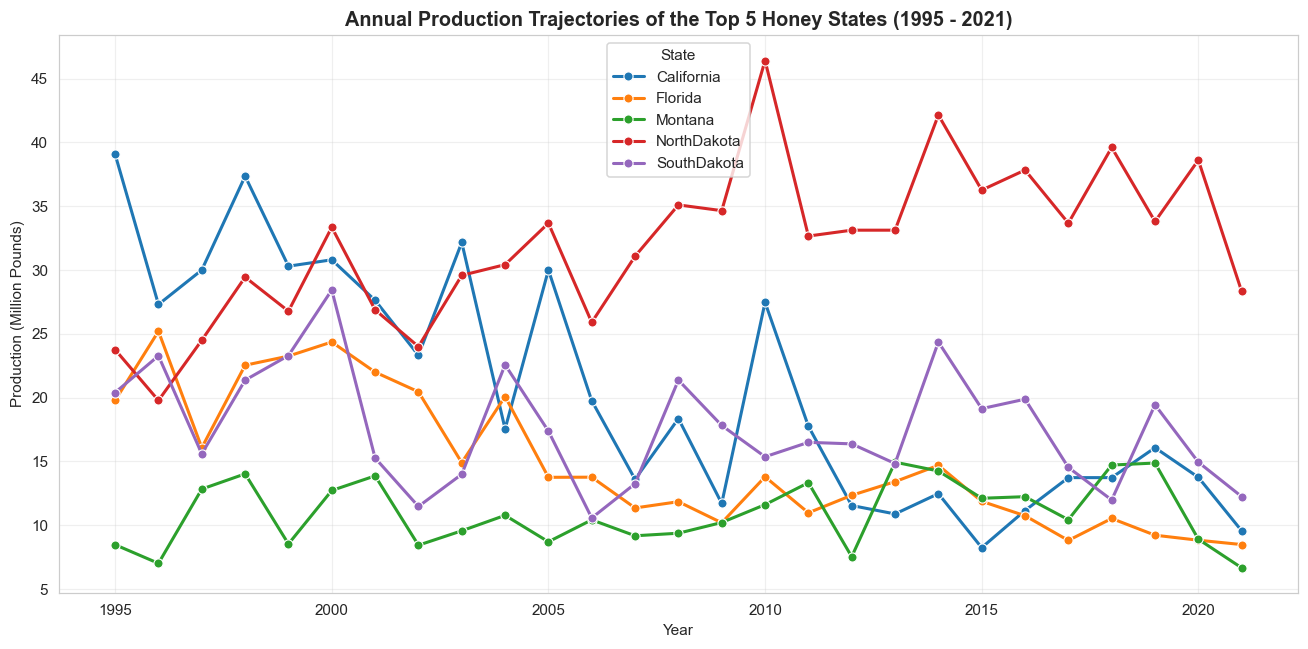

In [21]:
# Filter data for top 5 states
top_5_names = list(state_totals.head(5).index)
df_top5 = df[df['state'].isin(top_5_names)].copy()
df_top5['prod_millions'] = df_top5['actual_production'] / 1e6

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top5, x='year', y='prod_millions', hue='state', marker='o', linewidth=2)
plt.title('Annual Production Trajectories of the Top 5 Honey States (1995 - 2021)', fontsize=13, weight='bold')
plt.xlabel('Year')
plt.ylabel('Production (Million Pounds)')
plt.legend(title='State', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insights from Graph 9 (Top 5 States Trajectories):**
* **North Dakota Grew Rapidly**: North Dakota expanded from 25 million lbs in 1995 to reach an all-time peak of **46.4 million lbs** in 2010.
* **California Dropped Sharply**: California produced **39 million lbs** in 1995, but fell to just **10-15 million lbs** in recent years. This happened because of severe droughts and because beekeepers started renting their hives for almond pollination instead of making honey.
* **South Dakota and Montana**: Remained steady producers, harvesting between 10 and 20 million pounds each year.
* **Florida Fluctuates**: Florida suffered big drops in production after major hurricanes and citrus greening disease that damaged flowering orange groves.

---
### Graph 10: Colony Inventory Scale vs. Honey Output

Let's look at every state and year as a dot. The x-axis shows number of colonies (in thousands), the y-axis shows honey production (in million pounds), and color shows yield per colony.

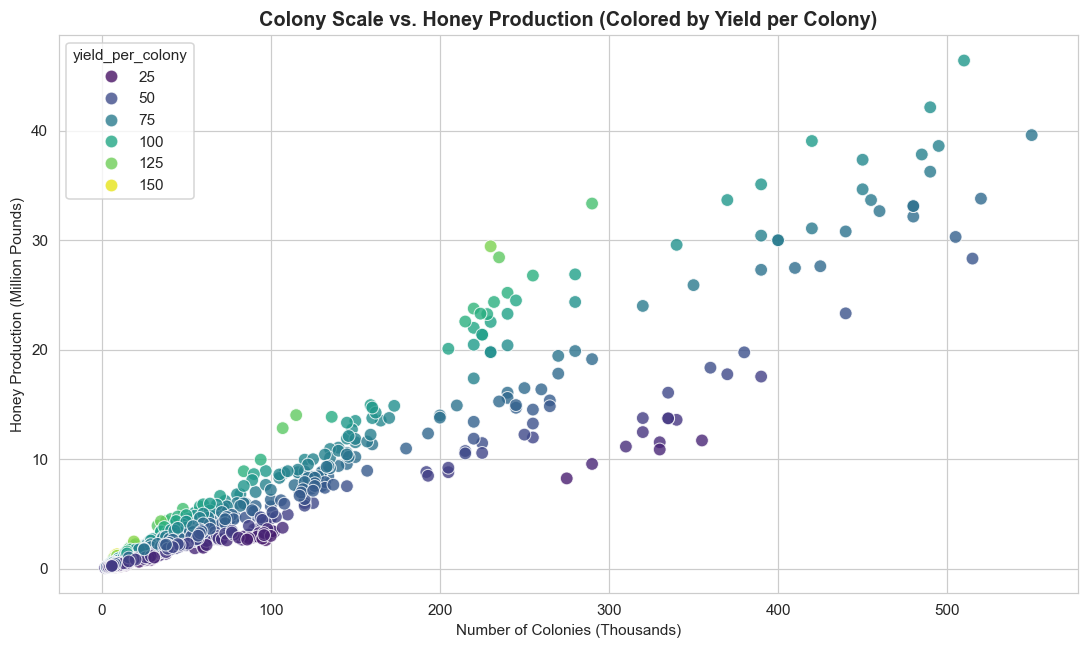

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x=df['colonies_number'] / 1000, 
    y=df['actual_production'] / 1e6, 
    hue='yield_per_colony', 
    palette='viridis', 
    alpha=0.8,
    s=70
)
plt.title('Colony Scale vs. Honey Production (Colored by Yield per Colony)', fontsize=13, weight='bold')
plt.xlabel('Number of Colonies (Thousands)')
plt.ylabel('Honey Production (Million Pounds)')
plt.tight_layout()
plt.show()

**Insights from Graph 10 (Scatter Plot):**
* **Most States are Small**: The vast majority of states sit in the bottom-left corner with fewer than **50,000 colonies** and under **5 million pounds** of honey.
* **Only Two Giants**: Only North Dakota and California ever cross 200,000 colonies and 20 million pounds.
* **Yield Makes a Huge Difference**: The bright yellow and green dots represent high-yield years (>80 lbs/colony). For the same number of hives, a high-yield year produces twice as much honey as a low-yield year.

---
### Graph 11: Hive Productivity Distribution (Pre-2006 vs. Post-2006)

To see the direct impact of Colony Collapse Disorder, let's split the dataset into two time periods: **Before 2006 (1995 to 2005)** and **After 2006 (2006 to 2021)** using a box plot.

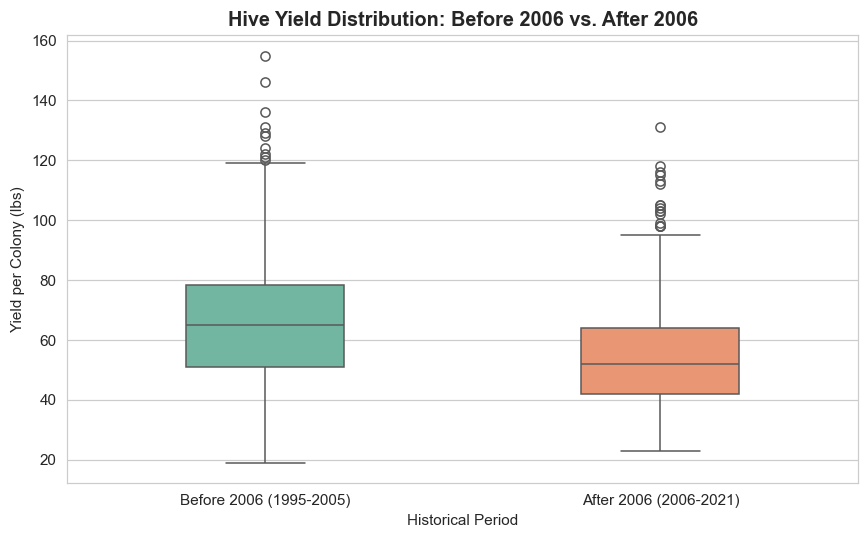

In [23]:
# Define historical eras
df['era'] = np.where(df['year'] < 2006, 'Before 2006 (1995-2005)', 'After 2006 (2006-2021)')

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='era', y='yield_per_colony', hue='era', palette='Set2', legend=False, width=0.4)
plt.title('Hive Yield Distribution: Before 2006 vs. After 2006', fontsize=13, weight='bold')
plt.xlabel('Historical Period')
plt.ylabel('Yield per Colony (lbs)')
plt.tight_layout()
plt.show()

**Insights from Graph 11 (Box Plot - Pre vs. Post 2006):**
* **Clear Drop in Median Yield**: The median yield dropped from **~65 lbs per colony** before 2006 down to **~53 lbs per colony** after 2006.
* **High Yield Seasons Disappeared**: Before 2006, top states often achieved yields of 90 to 120+ pounds per hive. After 2006, getting more than 90 pounds became extremely rare.
* **Permanent Downward Shift**: This boxplot proves that after 2006, beekeeping productivity suffered a permanent drop.

---
### Graph 12: Distribution of Annual State Honey Production

Finally, let's look at the distribution of annual honey production across all states and years using a histogram and density curve.

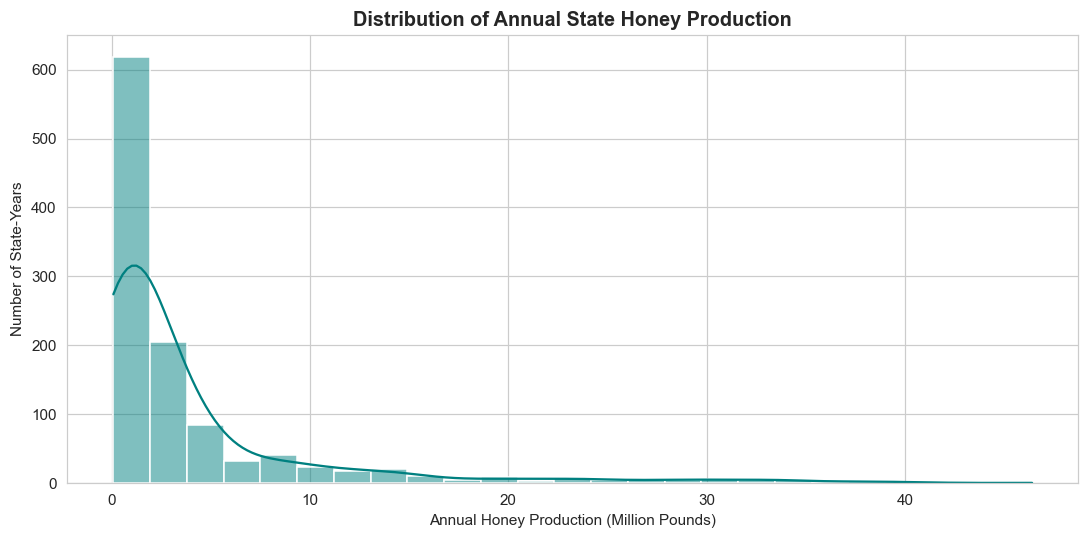

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(df['actual_production'] / 1e6, bins=25, kde=True, color='teal')
plt.title('Distribution of Annual State Honey Production', fontsize=13, weight='bold')
plt.xlabel('Annual Honey Production (Million Pounds)')
plt.ylabel('Number of State-Years')
plt.tight_layout()
plt.show()

**Insights from Graph 12 (Histogram):**
* **Right-Skewed Distribution**: Over **70% of state-year records** produce between 0 and 3 million pounds of honey.
* **Long Tail on the Right**: Only a small handful of top states produce large amounts between 15 and 46.4 million pounds.
* **Average vs Reality**: Because a few giant states produce so much honey, the national average looks high, but most states actually harvest much smaller amounts.

---
## Section 7: Final Summary and Key Takeaways

### Q&A: Important Questions Answered
* **Did honey production crash because bees died out?**
  No! In 2021, the US had **2.67 million colonies**, which is almost identical to the **2.64 million colonies** in 1995. Beekeepers actively split hives and bought new queens every year to keep hive counts steady.
* **Why did US honey production drop by 40.5%?**
  The main reason is **lower yield per hive**. Average production per hive dropped from **66.9 pounds in 1995** down to **46.7 pounds in 2021** (-30.2%). Colony Collapse Disorder (which began in 2006), loss of wildflowers, pesticides, and Varroa mites made hives less productive.
* **Did honey prices crash in 2018?**
  No! That was just an optical illusion in the raw dataset. The USDA reported prices in cents per pound up to 2017, and switched to dollars per pound in 2018. Honey prices actually reached an all-time record high of **$3.33 per pound** in 2021.
* **Which states produce the most honey?**
  Just 5 states—**North Dakota, California, South Dakota, Florida, and Montana**—produce **56.7%** of all honey in the United States.

### Main Numbers to Remember
* **Total National Production**: Fell from **210.3 million lbs (1995)** to **125.1 million lbs (2021)** (-40.5%).
* **Average Honey Price**: Rose from **$0.75/lb (1995)** to **$3.33/lb (2021)** (+345.5%).
* **All-Time Production Record**: **North Dakota in 2010** produced **46,410,000 pounds** (510,000 colonies with a yield of 91 lbs/colony).
* **All-Time Production Low**: **Maryland in 2003** produced **84,000 pounds** (2,000 colonies with a yield of 42 lbs/colony).
* **Colony Productivity Shift**: Median yield dropped from **~65 lbs/colony** before 2006 to **~53 lbs/colony** after 2006.

### Practical Lessons & Next Steps
* **Beekeepers shift to pollination services**: Because honey yield per hive has dropped, commercial beekeepers now make a big portion of their income by renting hives to pollinate almond, apple, and berry farms (especially California almonds) rather than just selling honey.
* **Ways to help honey bees**: To improve hive yields, agricultural policies should support planting native wildflower strips near farms, reducing harmful pesticide spraying during flowering times, and breeding bees that are naturally resistant to Varroa mites.